### Compute population-weighted anomalies of CMIP6 projection, ERA5, and forecast from xarrays

In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [3]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop", "gdppc", "iso3"]
]

In [4]:
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]

In [5]:
## CMIP6 Projections
ar6_project = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_ssp370_mon_201501-210012.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)
ar6_hist = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_historical_mon_185001-201412.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014118e+38)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/tmp/ipykernel_4976/1641687981.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(
/tmp/ipykernel_4976/1641687981.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014

In [6]:
# Preserve individual models and years
hist_mean_years = (
    ar6_hist["t"]
    .sel(time=slice("1995-01-01", "2014-12-31"))
)

hist_mean_years = hist_mean_years.assign_coords(
    year=hist_mean_years.time.dt.year, month=hist_mean_years.time.dt.month
)
hist_mean_years = hist_mean_years.set_index(time=["year", "month"]).unstack("time")

In [7]:
projection = ar6_project["t"]
projection = projection.assign_coords(
    year=projection.time.dt.year, month=projection.time.dt.month
)
projection = projection.set_index(time=["year", "month"]).unstack("time")

In [8]:
## Clean projections (NaN in upper latitudes)
projection = projection.chunk({"member": 'auto', "lat": -1, "lon": 30}).interpolate_na(dim="lat", method="linear")
hist_mean_years = hist_mean_years.chunk({"member": 'auto', "lat": -1, "lon": 30}).interpolate_na(dim="lat", method="linear")

In [9]:
#Keep only members in both hist and projection
common_members = np.intersect1d(hist_mean_years['member_id'], projection['member_id'])
#Concatenate on time
full_ds = xr.concat(
    [hist_mean_years.stack(time=["year", "month"]).sel(member_id=common_members),
     projection.stack(time=["year", "month"]).sel(member_id=common_members)],
    dim='time'
)

In [10]:
#Gridded -> Pop-Weighted Average of CMIP6
cmip6_ir = isku_utils.grid_to_ir(full_ds)
merged_cmip6 = xr.merge([cmip6_ir.rename('temp'), socioeconomics.drop_vars('year')])
pop_weighted_anomaly_cmip6 = (merged_cmip6['temp'] * merged_cmip6['pop']).sum(dim='region') / merged_cmip6['pop'].sum(dim='region')

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [14]:
# Restore Time Dimension
da_time = pop_weighted_anomaly_cmip6.drop_vars(["time", "year", "month"]).assign_coords(
    time=pd.to_datetime(
        [f"{y}-{m:02d}-01" for y, m in zip(pop_weighted_anomaly_cmip6.year.values, pop_weighted_anomaly_cmip6.month.values)]
    )
).sortby("time")
#da_time = da_time.compute()
#Save raw CMIP6 Temps
#da_time.to_zarr("pop_weighted_cmip6.zarr")

In [15]:
#Compute monthly anomaly w/ baseline 1995-2014
cmip6_anomaly = da_time.groupby('time.month')-da_time.sel(time = slice('1995-01-01', '2014-12-31')).groupby('time.month').mean()

In [16]:
#CMIP6 Forecast Month Annual Average
selected_cmip6 = cmip6_anomaly.where(cmip6_anomaly['month'].isin(FC_MONTHS), drop=True)
rolled_cmip6 = (selected_cmip6.groupby('time.year').mean(dim='time')
                   .rename(year='time')
                   .rolling(time=10, center=False).mean())
lower_cmip6 = rolled_cmip6.quantile(0.17, dim='member')
upper_cmip6 = rolled_cmip6.quantile(0.83, dim='member')

combined_cmip6 = xr.Dataset({
    'lower': lower_cmip6.drop_vars('quantile'),
    'upper': upper_cmip6.drop_vars('quantile'),
    'mean': rolled_cmip6.mean(dim='member'),
}).to_dataframe()

combined_cmip6.to_csv('pop_weighted_temp_cmip6_members_proj_09.csv')

(np.float64(12784.0), np.float64(32872.0))

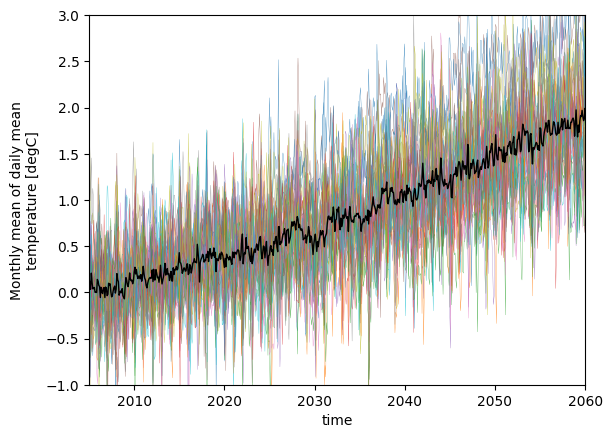

In [ ]:
# Monthly Plot
cmip6_anomaly.plot.line(x = 'time', linewidth = 0.2, add_legend = False)
cmip6_anomaly.mean(dim = 'member').plot(linewidth = 1, color = 'black', add_legend = False)
plt.ylim(-1, 3)
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2060-01-01'))

(np.float64(12784.0), np.float64(32872.0))

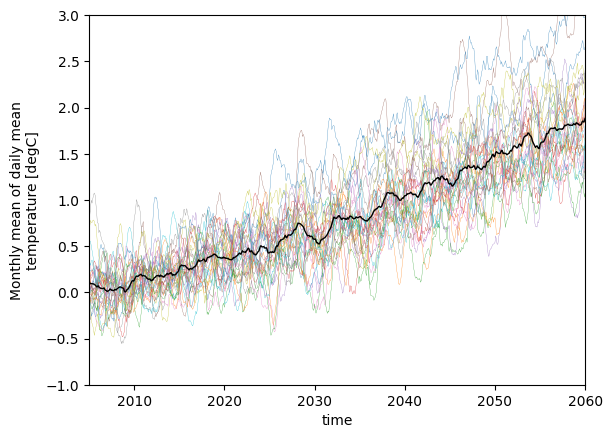

In [ ]:
# 10 year rolling average
cmip6_anomaly.rolling(time=10, center=False).mean().plot.line(x = 'time', linewidth = 0.2, add_legend = False)
cmip6_anomaly.rolling(time=10, center=False).mean().mean(dim = 'member').plot(linewidth = 1, color = 'black', add_legend = False)
plt.ylim(-1, 3)
plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2060-01-01'))

(-1.0, 3.0)

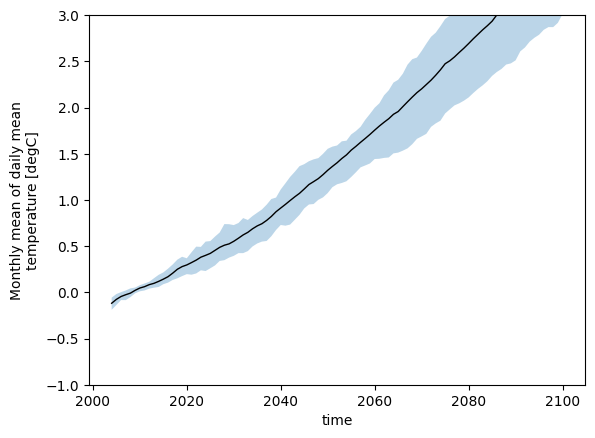

In [ ]:
plt.fill_between(rolled['time'], lower, upper, alpha=0.3, linewidth=0)
rolled.mean(dim = 'member').plot(linewidth = 1, color = 'black', add_legend = False)
plt.ylim(-1, 3)
#plt.xlim(pd.to_datetime('2005-01-01'), pd.to_datetime('2060-01-01'))

In [5]:
POREALLAS_PARSED_ERA5_URI = "gs://poreallas-public-20260605/v20260731/parsed/era5.zarr"
ERA5_RECENT = "/home/emily_zuetell/projects/poreallas/data/parsed/26_era5_daily_running.zarr"
POREALLAS_PARSED_FORECAST_URI = "/home/emily_zuetell/projects/poreallas/data/parsed/v20260903_parsed_forecast.zarr"

In [6]:
forecast = xr.open_zarr(
        POREALLAS_PARSED_FORECAST_URI)

In [ ]:
era5 = xr.open_dataset(
        POREALLAS_PARSED_ERA5_URI,
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
    ).resample(time='MS').mean()
era5_recent = xr.open_zarr(ERA5_RECENT).resample(time='MS').mean().rename({'t2m': 'tas'})
era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 ERA5 data

In [7]:
# Baseline period Monthly Climatology
BASELINE_PERIOD = slice("1995-01-01", "2014-12-31")

In [8]:
forecast_base = forecast.sel(time=BASELINE_PERIOD).groupby('time.month').mean().mean(dim = 'number')

In [ ]:

era5_base = era5.sel(time=BASELINE_PERIOD).groupby('time.month').mean()


In [9]:
### Anomaly
# Analysis Period (1995-2027)
forecast_analysis = forecast.sel(time=slice("2026-08-01", "2027-02-28")).resample(time='MS').mean()

# Subtract Monthly Climatology
forecast_anomaly = forecast_analysis.groupby('time.month') - forecast_base

In [100]:
### Anomaly
# Analysis Period (1995-2027)
era5_analysis = era5_full.sel(time=slice("1995-01-01", "2026-07-31")).resample(time='MS').mean()
forecast_analysis = forecast.sel(time=slice("2026-08-01", "2027-02-28")).resample(time='MS').mean()

# Subtract Monthly Climatology
era5_anomaly = era5_analysis.groupby('time.month') - era5_base
forecast_anomaly = forecast_analysis.groupby('time.month') - forecast_base

In [ ]:
# Pop-Weighted
# Convert Ensemble Average to Impact Regions
era5_ir_anomaly = isku_utils.grid_to_ir(era5_anomaly['tas'])
merged_era5 = xr.merge([era5_ir_anomaly.rename('anomaly'), socioeconomics])
pop_weighted_anomaly_era5 = (merged_era5['anomaly'] * merged_era5['pop']).sum(dim='region') / merged_era5['pop'].sum(dim='region')



In [10]:
forecast_ir_anomaly = isku_utils.grid_to_ir(forecast_anomaly['tas'])
merged_forecast = xr.merge([forecast_ir_anomaly.rename('anomaly'), socioeconomics])
pop_weighted_anomaly_forecast = (merged_forecast['anomaly'] * merged_forecast['pop']).sum(dim='region') / merged_forecast['pop'].sum(dim='region')

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [11]:
rolled_forecast = pop_weighted_anomaly_forecast
lower_forecast = rolled_forecast.quantile(0.17, dim='number')
upper_forecast = rolled_forecast.quantile(0.83, dim='number')

combined_forecast = xr.Dataset({
    'lower': lower_forecast.drop_vars('quantile'),
    'upper': upper_forecast.drop_vars('quantile'),
    'mean': rolled_forecast.mean(dim='number'),
}).to_dataframe()
combined_forecast.to_csv('2609_pop_weighted_anomaly_forecast_members.csv')